In [1]:
from google.colab import files

print("Please upload your 'dataset_multiclasse_19_pathologies.xlsx' file.")
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


ModuleNotFoundError: No module named 'google.colab'

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Chargement des données
df = pd.read_excel('dataset_multiclasse_19_pathologies.xlsx')

# 2. Séparation Features (X) et Cible (y)
# On prend l'Age, le BPM, le SpO2 et la Température
X = df[['Age', 'BPM', 'SpO2', 'Temperature']].values

# On prend l'ID de la classe (1 à 19).
y = df['ID_Classe_Predite'].values - 1

# 3. Division en sets d'Entraînement (80%) et de Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. NORMALISATION (Étape cruciale pour le Deep Learning)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Sauvegarder le scaler pour plus tard
# Tu en auras besoin pour ton code PHP/Flutter afin de normaliser
# les données réelles de la même manière que l'entraînement.
joblib.dump(scaler, 'scaler_medbox.pkl')

print(f"Données prêtes !")
print(f"Forme de X_train : {X_train_scaled.shape}")
print(f"Exemple de donnée normalisée : {X_train_scaled[0]}")

Données prêtes !
Forme de X_train : (7600, 4)
Exemple de donnée normalisée : [-0.80399381  0.12584036  0.93513998 -0.19155087]


**Entrainemment du modèle AI**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# 1. Préparation des labels pour la classification multiclasse
# Keras a besoin que les labels soient au format "One-Hot Encoded"
# Exemple : la classe 3 devient [0, 0, 0, 1, 0, 0, ...]
y_train_encoded = to_categorical(y_train, num_classes=19)
y_test_encoded = to_categorical(y_test, num_classes=19)

# 2. Définition de l'architecture du Réseau de Neurones (MLP)
model = Sequential([
    # Couche d'entrée implicite (4 caractéristiques) + 1ère couche cachée
    Dense(32, activation='relu', input_shape=(4,)),
    Dropout(0.1), # Évite le surapprentissage en désactivant 10% des neurones aléatoirement

    # 2ème couche cachée
    Dense(16, activation='relu'),

    # Couche de sortie : 19 neurones pour les 19 cas possibles
    # L'activation Softmax donne une probabilité (ex: 0.95 pour le cas 15)
    Dense(19, activation='softmax')
])

# 3. Compilation du modèle
model.compile(
    optimizer='adam', # Algorithme d'optimisation standard et efficace
    loss='categorical_crossentropy', # Fonction de perte idéale pour le multiclasse
    metrics=['accuracy'] # Nous voulons suivre le score de précision
)

# 4. Entraînement du modèle
print("Début de l'entraînement...")
history = model.fit(
    X_train_scaled, y_train_encoded,
    validation_data=(X_test_scaled, y_test_encoded),
    epochs=50,       # Nombre de passages sur l'ensemble des données
    batch_size=32,   # Taille des paquets de données traités à la fois
    verbose=1
)

# 5. Évaluation finale sur les données de Test
loss, accuracy = model.evaluate(X_test_scaled, y_test_encoded, verbose=0)
print(f"\n--- RÉSULTAT FINAL ---")
print(f"Score de précision (Accuracy) sur le jeu de test : {accuracy * 100:.2f}%")

# 6. Sauvegarde du modèle au format Keras standard
#model.save('model_medbox.h5')
#print("Modèle sauvegardé sous 'model_medbox.h5'")

Début de l'entraînement...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3012 - loss: 2.3910 - val_accuracy: 0.5632 - val_loss: 1.6497
Epoch 2/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6426 - loss: 1.2396 - val_accuracy: 0.7874 - val_loss: 0.8660
Epoch 3/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7682 - loss: 0.7743 - val_accuracy: 0.8532 - val_loss: 0.5663
Epoch 4/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8055 - loss: 0.5821 - val_accuracy: 0.8689 - val_loss: 0.4394
Epoch 5/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8334 - loss: 0.4890 - val_accuracy: 0.8847 - val_loss: 0.3668
Epoch 6/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8426 - loss: 0.4447 - val_accuracy: 0.8968 - val_loss: 0.3276
Epoch 7/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8495 - loss: 0.4054 - val_accuracy: 0.8989 - val_loss: 0.3053
Epoch 8/50
238/238 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8591 - loss: 0.3808 - val_accuracy: 0.9111 - val_

Avec 95.58% d'accuracy sur mon test_set, je garde ce modèle et code une matrice de confusion.

Calcul des prédictions sur le jeu de test...
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


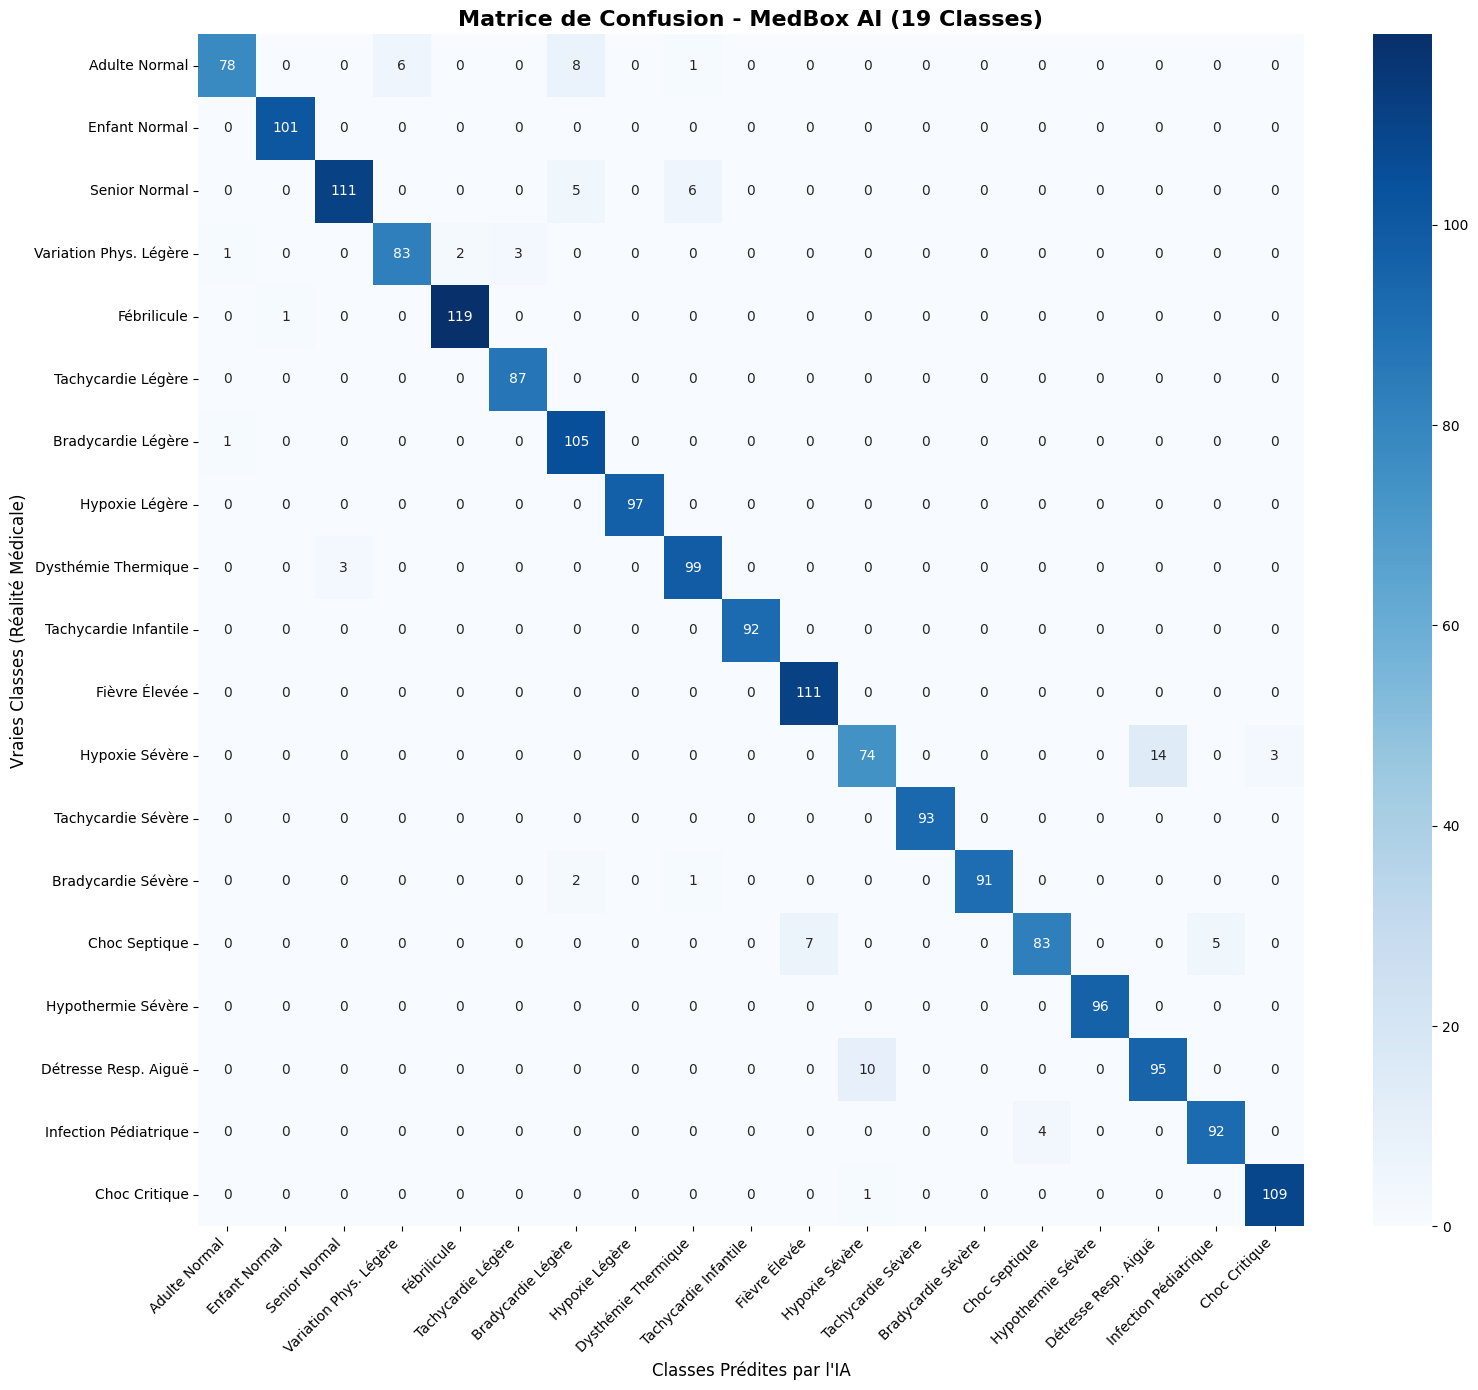

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Obtenir les prédictions du modèle sur le jeu de test (20%)
print("Calcul des prédictions sur le jeu de test...")
y_pred_probabilities = model.predict(X_test_scaled)

# Convertir les probabilités (Softmax) en indices de classe (0 à 18)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# 2. Générer la matrice de confusion brute
# y_test contient les vraies classes, y_pred contient les prédictions
cm = confusion_matrix(y_test, y_pred)

# 3. Récupérer les noms exacts des 19 cas pour les étiquettes (Labels)
# On récupère l'ordre exact des classes depuis ton dataset d'origine
class_names = [
    "Adulte Normal", "Enfant Normal", "Senior Normal", "Variation Phys. Légère",
    "Fébrilicule", "Tachycardie Légère", "Bradycardie Légère", "Hypoxie Légère",
    "Dysthémie Thermique", "Tachycardie Infantile", "Fièvre Élevée", "Hypoxie Sévère",
    "Tachycardie Sévère", "Bradycardie Sévère", "Choc Septique", "Hypothermie Sévère",
    "Détresse Resp. Aiguë", "Infection Pédiatrique", "Choc Critique"
]

# 4. Affichage graphique avec Seaborn
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,          # Affiche le nombre d'exemples dans chaque case
    fmt='d',             # Format entier pour les nombres
    cmap='Blues',        # Couleur dégradée bleue
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title('Matrice de Confusion - MedBox AI (19 Classes)', fontsize=16, fontweight='bold')
plt.ylabel('Vraies Classes (Réalité Médicale)', fontsize=12)
plt.xlabel('Classes Prédites par l\'IA', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Sauvegarder l'image pour ton rapport écrit
plt.savefig('matrice_confusion_medbox.png', dpi=300)
plt.show()

la matrice de confusions donne un bon,beau graphique avec des confusion généralement sur les cas phisiologique proche ce qui est totalement comprehensif

In [ ]:
model.save('model_medbox.h5')
print("Modèle sauvegardé sous 'model_medbox.h5'")


Modèle sauvegardé sous 'model_medbox.h5'


In [ ]:
import joblib

# 1. Charger le scaler sauvegardé
scaler = joblib.load('scaler_medbox.pkl')

# 2. Afficher les constantes apprises par le modèle
print("--- CONSTANTES À COPIER DANS L'ESP32 ---")
print("Moyennes (Age, BPM, SpO2, Temp) :", scaler.mean_)
print("Écarts-types (Age, BPM, SpO2, Temp) :", scaler.scale_)

--- CONSTANTES À COPIER DANS L'ESP32 ---
Moyennes (Age, BPM, SpO2, Temp) : [ 40.76118421 100.52855263  93.3425      37.05082895]
Écarts-types (Age, BPM, SpO2, Temp) : [24.57877655 35.5326977   6.04989639  1.83151845]


**Modèle en Tflite**




In [ ]:
import tensorflow as tf

# 1. Charger le modèle Keras que tu viens d'entraîner
model = tf.keras.models.load_model('model_medbox.h5')

# 2. Configurer le convertisseur TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Étape cruciale : On active l'optimisation par défaut (Quantisation)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# 3. Exécuter la conversion
tflite_model = converter.convert()

# 4. Sauvegarder le modèle au format .tflite (pour sauvegarde)
with open('../../Téléchargements/model_medbox.tflite', 'wb') as f:
    f.write(tflite_model)
print("-> Fichier 'model_medbox.tflite' généré avec succès.")

# 5. Génération automatique du fichier C++ 'model_medbox.h' pour l'ESP32
bytes_array = list(tflite_model)
header_content = f"""/* * Modèle TensorFlow Lite quantifié pour MedBox AI
 * Précision d'entraînement : 95.63%
 * Généré automatiquement pour l'ESP32
 */

#ifndef MODEL_MEDBOX_H
#define MODEL_MEDBOX_H

const unsigned char model_medbox_tflite[] alignas(8) = {{
"""

# Structurer l'affichage proprement (12 octets par ligne)
for i, b in enumerate(bytes_array):
    if i % 12 == 0:
        header_content += "\n  "
    header_content += f"0x{b:02x}, "

header_content += f"""
}};
const unsigned int model_medbox_tflite_len = {len(bytes_array)};

#endif // MODEL_MEDBOX_H
"""

# Écriture du fichier header
with open('../../Téléchargements/model_medbox.h', 'w') as f:
    f.write(header_content)

print("-> Fichier C++ 'model_medbox.h' prêt à être copié dans ton projet Arduino !")

Saved artifact at '/tmp/tmp499ek03y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 19), dtype=tf.float32, name=None)
Captures:
  140046953422992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140046953426256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140046953427600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140046953428368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140046953429328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140046953428560: TensorSpec(shape=(), dtype=tf.resource, name=None)
-> Fichier 'model_medbox.tflite' généré avec succès.
-> Fichier C++ 'model_medbox.h' prêt à être copié dans ton projet Arduino !


In [ ]:
import numpy as np
import tensorflow as tf

# 1. Charger le modèle quantifié (.tflite)
interpreter = tf.lite.Interpreter(model_path="../../Téléchargements/model_medbox.tflite")
interpreter.allocate_tensors()

# Récupérer les index d'entrée et de sortie
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# 2. Tester le modèle sur toutes les données de test
bonnes_predictions = 0

for i in range(len(X_test_scaled)):
    # Préparer la donnée comme le fera l'ESP32
    input_data = np.array([X_test_scaled[i]], dtype=np.float32)
    interpreter.set_tensor(input_details[0]['index'], input_data)

    # Lancer le calcul (l'inférence)
    interpreter.invoke()

    # Récupérer le résultat
    output_data = interpreter.get_tensor(output_details[0]['index'])
    classe_predite = np.argmax(output_data[0])

    # Vérifier si c'est correct
    if classe_predite == y_test[i]:
        bonnes_predictions += 1

# 3. Calculer l'accuracy finale quantifiée
accuracy_tflite = (bonnes_predictions / len(X_test_scaled)) * 100
print(f"Accuracy du modèle d'origine (Keras) : 95.58 %")
print(f"Accuracy du modèle compressé (TFLite) : {accuracy_tflite:.2f} %")

Accuracy du modèle d'origine (Keras) : 95.63 %
Accuracy du modèle compressé (TFLite) : 95.58 %


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
